# Exploring the log-determinant of gapped LISA covariances

**Three routes to $\log|\Sigma_{OO}|$ under flexible noise models: dense Cholesky, stochastic Lanczos quadrature (SLQ), and the Schur-complement identity.**

This notebook is a self-contained tutorial companion to `SUMMARY.md` and `lanczos_determinant_study.md`. Every computational path shown here is the *tested library path* (`gaplike.slq`, `gaplike.cg`; see `tests/test_slq.py`), not a reimplementation, and every stochastic step is seeded. Timings are single-shot wall times on a multithreaded laptop — indicative, not benchmarks; the scripts in `paper/` report minima over repeats.

## The statistical object

The exact time-domain likelihood of stationary Gaussian noise observed through gaps is

$$\log \mathcal{L}(\theta) \;=\; -\tfrac12\, d^{\mathsf T} \Sigma_{OO}(\theta)^{-1} d \;-\; \tfrac12 \log\lvert\Sigma_{OO}(\theta)\rvert \;-\; \tfrac m2 \log 2\pi ,$$

where $\Sigma_{OO} = R\,\Sigma\,R^{\mathsf T}$ is the full covariance restricted to the $m$ observed samples (rows/columns of the gaps deleted). In the circulant model used throughout `gaplike`, $\Sigma$ has DFT eigenvalues $\lambda_f = S_2(f;\theta)/(2\Delta t)$, so matrix–vector products cost two FFTs — but $\Sigma_{OO}$ itself is neither circulant nor Toeplitz.

The quadratic form is handled matrix-free by preconditioned CG (`gaplike.cg`). The determinant is the harder half: it must be re-evaluated at **every noise-parameter update**, and with a flexible (spline) noise model there is no closed form. Note what a sampler actually consumes: the accept ratio needs the **difference** $\Delta = \log|\Sigma_{OO}(\theta')| - \log|\Sigma_{OO}(\theta)|$, not absolute values — this distinction drives everything below.

## The flexible noise model

$$S(f; \mathbf c) \;=\; S_{\mathrm{ref}}(f)\, \exp\Big(\sum_{k=1}^{K} c_k\, B_k(\log_{10} f)\Big),$$

a cubic B-spline log-ratio on top of the TDI-2 A-channel reference spectrum: $\mathbf c = 0$ reproduces the reference exactly, and MCMC proposals perturb $\mathbf c$ by small steps.

N = 2^12 = 4096 samples (17.1 h at 15 s), observed m = 3276, gap g = 820 (duty 80%)


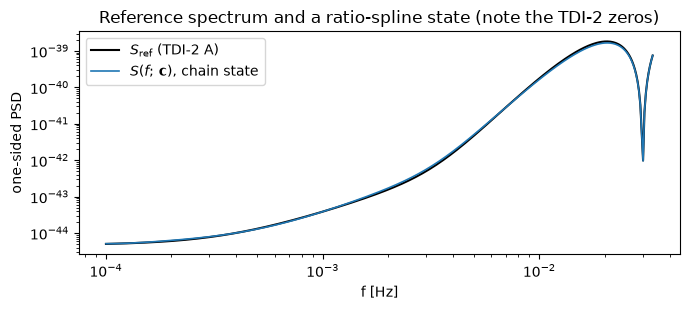

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cho_factor

from gaplike import cg as gcg
from gaplike import gaps, psd, slq

# ----------------------------- configuration --------------------------------
DT      = 15.0          # cadence [s]
K_DEMO  = 12            # detailed sections run at N = 2**K_DEMO (~17 h)
N_GAP, PERIOD = 10, 50  # scenario-C comb: 80% duty, LISA-like
N_COEFF = 12            # spline coefficients
SEED    = 0

n   = 2 ** K_DEMO
obs = np.flatnonzero(np.asarray(gaps.periodic_mask(n, N_GAP, PERIOD)) > 0)
gap = np.setdiff1d(np.arange(n), obs)
m, g = obs.size, gap.size
print(f"N = 2^{K_DEMO} = {n} samples ({n*DT/3600:.1f} h at {DT:.0f} s), "
      f"observed m = {m}, gap g = {g} (duty {m/n:.0%})")

comps  = psd.lisa_tdi2_ae()
S_ref  = lambda f: comps["tm"](f) + comps["oms"](f)
f_nyq  = 1.0 / (2 * DT)
knots  = slq.spline_knots(1e-4, f_nyq, N_COEFF)
rng    = np.random.default_rng(SEED)

c_state = 0.1 * rng.standard_normal(N_COEFF)          # the current chain state
eig1 = gcg.circulant_eigenvalues([slq.ratio_spline(S_ref, knots, c_state)], n, DT)

ff = np.geomspace(1e-4, f_nyq, 400)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.loglog(ff, S_ref(ff), "k-", lw=1.5, label=r"$S_{\rm ref}$ (TDI-2 A)")
ax.loglog(ff, slq.ratio_spline(S_ref, knots, c_state)(ff), "-", lw=1.2,
          label=r"$S(f;\,\mathbf{c})$, chain state")
ax.set_xlabel("f [Hz]"); ax.set_ylabel("one-sided PSD"); ax.legend()
ax.set_title("Reference spectrum and a ratio-spline state (note the TDI-2 zeros)")
plt.tight_layout(); plt.show()

## Route 1 — dense Cholesky (the ground truth, and the wall)

Build $\Sigma_{OO}$ from the autocovariance $\gamma_j = \tfrac1n\sum_f \lambda_f e^{2\pi i jf/n}$ (one inverse FFT, then a lag table on the observed indices), factor $\Sigma_{OO} = LL^{\mathsf T}$, and read off

$$\log|\Sigma_{OO}| = 2\sum_{i} \log L_{ii}.$$

Exact to floating point; cost $\mathcal O(m^3)$ flops and $\mathcal O(m^2)$ memory ($\sim$1.4 GB at $N=2^{14}$, $\sim$350 GB at $2^{18}$ — the wall that motivates everything else). This is the notebook's truth standard wherever it is affordable.

In [2]:
t0 = time.perf_counter()
ld_dense, t_chol = slq.logdet_dense(eig1, obs)     # build + Cholesky
t_dense = time.perf_counter() - t0
print(f"dense:  log|Sigma_OO| = {ld_dense:.8e}")
print(f"        build+factor {t_dense:.3f} s (factorisation alone {t_chol:.3f} s), "
      f"memory ~{m*m*8/1e6:.0f} MB")

dense:  log|Sigma_OO| = -3.11785634e+05
        build+factor 0.076 s (factorisation alone 0.034 s), memory ~86 MB


## Route 2 — stochastic Lanczos quadrature (SLQ)

Two classical ingredients (Ubaru, Chen & Saad 2017):

**Hutchinson's estimator.** For symmetric $A$ and random probes with $\mathbb E[zz^{\mathsf T}] = I$,
$$\operatorname{tr} f(A) = \mathbb E\big[z^{\mathsf T} f(A)\, z\big] \approx \frac1M \sum_{i=1}^{M} z_i^{\mathsf T} f(A)\, z_i .$$
With **Rademacher** probes ($z_j = \pm1$) the single-probe variance is
$$\operatorname{Var}\big[z^{\mathsf T} A z\big] = 2\big(\lVert A\rVert_F^2 - \textstyle\sum_i A_{ii}^2\big)$$
— *the diagonal does not contribute*. Keep that fact in mind for differences.

**Lanczos quadrature.** Each $z^{\mathsf T} \log(A)\, z$ is a Riemann–Stieltjes integral against the spectral measure of $A$ seen from $z$; $k$ Lanczos steps build the tridiagonal $T_k$ whose eigenpairs $(\theta_j, \tau_j)$ ($\tau_j$ = first component of the $j$-th eigenvector) give the Gauss-quadrature rule
$$z^{\mathsf T} \log(A)\, z \;\approx\; \lVert z\rVert^2 \sum_{j=1}^{k} \tau_j^2\, \log \theta_j .$$
Matrix access is only through products $Av$ — two FFTs here.

**Implementation notes, validated not assumed:** the fast batched path runs *without* reorthogonalisation (standard SLQ practice; orthogonality loss duplicates Ritz values, which the quadrature tolerates). On these operators the no-reorth estimates agree with full reorthogonalisation to $<10^{-3}$ log-likelihood units and with dense truth within scatter — enforced by `test_no_reorth_accuracy`. Full reorthogonalisation is retained as an option (and is *slower* when batched: the stored-basis re-reads are memory-bandwidth bound — see `SUMMARY.md` F3).

In [3]:
M_PROBES, K_LANCZOS = 32, 100
t0 = time.perf_counter()
out = slq.logdet_slq(eig1, obs, n_probes=M_PROBES, k=K_LANCZOS,
                     rng=np.random.default_rng(SEED))
t_slq = time.perf_counter() - t0
se = out["per_probe"].std(ddof=1) / np.sqrt(M_PROBES)
print(f"SLQ ({M_PROBES} probes x {K_LANCZOS} Lanczos steps, no reorth, batched):")
print(f"        estimate {out['est']:.8e}   (dense truth {ld_dense:.8e})")
print(f"        abs. error {abs(out['est']-ld_dense):9.3f} LL units, "
      f"standard error {se:.2f}, time {t_slq:.3f} s")
print(f"        relative error {abs(out['est']-ld_dense)/abs(ld_dense):.2e}"
      "  <- excellent RELATIVELY, useless ABSOLUTELY for an accept ratio")

SLQ (32 probes x 100 Lanczos steps, no reorth, batched):
        estimate -3.11735348e+05   (dense truth -3.11785634e+05)
        abs. error    50.286 LL units, standard error 42.62, time 0.183 s
        relative error 1.61e-04  <- excellent RELATIVELY, useless ABSOLUTELY for an accept ratio


### The estimator a sampler actually needs: shared-probe differences

The accept ratio needs $\Delta = \operatorname{tr}\big[\log \Sigma_{OO}(\mathbf c') - \log \Sigma_{OO}(\mathbf c)\big]$. Estimate the **difference operator directly**, using the *same* probes on both operators:

$$\widehat\Delta = \frac1M \sum_{i=1}^{M}\Big[ z_i^{\mathsf T} \log\big(\Sigma_{OO}(\mathbf c')\big) z_i - z_i^{\mathsf T} \log\big(\Sigma_{OO}(\mathbf c)\big) z_i \Big].$$

Its variance is governed by $D = \log\Sigma_{OO}(\mathbf c') - \log\Sigma_{OO}(\mathbf c)$ — small for an MCMC step, and (under a smooth spectral perturbation) with most of its energy on the diagonal, which Rademacher probes do not feel. Differencing two *independently probed* absolute estimates instead pays the full variance of two $\sim10^{5}$-magnitude quantities. The cell measures both against dense truth.

In [4]:
sigma_step = 0.01                        # MCMC-sized proposal
delta   = sigma_step * rng.standard_normal(N_COEFF)
eig2    = gcg.circulant_eigenvalues(
    [slq.ratio_spline(S_ref, knots, c_state + delta)], n, DT)
ld2, _  = slq.logdet_dense(eig2, obs)
truth_D = ld2 - ld_dense
res_sh = slq.logdet_diff_slq(eig1, eig2, obs, 16, K_LANCZOS,
                             np.random.default_rng(SEED + 1), shared=True)
res_in = slq.logdet_diff_slq(eig1, eig2, obs, 16, K_LANCZOS,
                             np.random.default_rng(SEED + 1), shared=False)
print(f"truth        Delta = {truth_D:+.4f} LL")
for name, r in (("shared", res_sh), ("independent", res_in)):
    std = r["per_probe"].std(ddof=1)
    print(f"{name:>12}: est {r['est']:+9.4f}  |err| {abs(r['est']-truth_D):7.3f}  "
          f"per-probe std {std:8.3f}")
print(f"variance ratio (independent/shared): "
      f"{(res_in['per_probe'].std(ddof=1)/res_sh['per_probe'].std(ddof=1))**2:,.0f}x")

truth        Delta = +10.6361 LL
      shared: est  +10.6899  |err|   0.054  per-probe std    0.204
 independent: est  +47.0289  |err|  36.393  per-probe std  234.323
variance ratio (independent/shared): 1,320,025x


## Route 3 — the Schur-complement identity: stop estimating

Partition the **full** covariance over observed ($O$) and gap ($G$) samples. Two standard facts about SPD block matrices — the block-determinant factorisation and the block-inverse formula —

$$|\Sigma| = |\Sigma_{OO}|\cdot\big|\Sigma_{GG} - \Sigma_{GO}\Sigma_{OO}^{-1}\Sigma_{OG}\big|, \qquad (\Sigma^{-1})_{GG} = \big(\Sigma_{GG} - \Sigma_{GO}\Sigma_{OO}^{-1}\Sigma_{OG}\big)^{-1}$$

combine into an **exact identity** (any SPD $\Sigma$, any gap pattern):

$$\boxed{\;\log|\Sigma_{OO}| \;=\; \log|\Sigma| \;+\; \log\big|(\Sigma^{-1})_{GG}\big|\;}$$

### Where does $(\Sigma^{-1})_{GG}$ come from? Model, not data

Three things must not be conflated here — this is where the identity looks like sleight of hand until they are separated.

**The data are missing; the covariance is not.** $\Sigma$ is never built from data: it is the *model* covariance of the underlying stationary process on the full time grid, with entries $\Sigma_{ij} = \gamma(t_i - t_j)$ given by the PSD through Wiener–Khinchin. The process exists during the gaps — the instrument simply did not record it — and stationarity specifies its correlation with every other epoch as a function of lag alone. Every block ($\Sigma_{GG}$, $\Sigma_{OG}$, …) is therefore a well-defined array of numbers computable from $S(f)$ with no data at all. Zero-*filling* appears only inside matrix–vector products as the embedding $R^{\mathsf T}$ — an algebraic device, never a statement about the data.

**Order of operations: $(\Sigma^{-1})_{GG} \neq (\Sigma_{GG})^{-1}$.** The identity uses the gap block *of the full inverse*: invert the $n\times n$ covariance first, then read off the $G$ rows and columns. Inverting the full $\Sigma$ sounds expensive — but in the circulant model $\Sigma = F^{\mathsf H}\,\mathrm{diag}(\lambda)\,F$, so $\Sigma^{-1} = F^{\mathsf H}\,\mathrm{diag}(1/\lambda)\,F$ is *also* circulant: its kernel is one inverse FFT of the entrywise-inverted eigenvalues, $\gamma_{\rm inv} = \mathrm{Re}\,\mathrm{ifft}(1/\lambda)$, and the block is that kernel indexed at gap-lag pairs. In code this is a single line: `dense_restricted(1.0 / ef, gap)`. The diagonalising basis performs the inversion for free; "access" to the block is just picking entries of an analytically known function.

**What the object means.** The observed-data likelihood *is* the marginal $p(x_O) = \int p(x_O, x_G)\, \mathrm d x_G$, and the Gaussian integral over the unrecorded samples contributes the determinant of their *conditional* covariance given the observed ones — which, by the block-inverse lemma, is $\mathrm{Cov}(x_G \mid x_O) = \big[(\Sigma^{-1})_{GG}\big]^{-1}$. The identity is thus the marginalisation's bookkeeping,

$$\log|\Sigma_{OO}| \;=\; \log|\Sigma| \;-\; \log\big|\mathrm{Cov}(x_G \mid x_O)\big|,$$

the full determinant minus the piece belonging to what was never observed, *conditioned on what was*. This also locates the method in the literature: gap data-augmentation schemes (e.g. Baghi et al. 2019) draw $x_G \sim p(x_G \mid x_O)$ — the same conditional — and the complement identity is what remains when that imputation is integrated out analytically instead of sampled.

In the circulant model both ingredients are cheap: $\log|\Sigma| = \sum_f \log\lambda_f$ is the closed-form Whittle sum, and $\Sigma^{-1}$ is the circulant with eigenvalues $1/\lambda_f$ — so $(\Sigma^{-1})_{GG}$ is a *dense build on the $g$ gap samples*, and the whole determinant costs **one $g\times g$ Cholesky**. At 80% duty that is $(m/g)^3 = 64\times$ fewer flops than dense on the observed side, and it is exact.

The same partition algebra gives the inverse — with $A = \Sigma^{-1}$,
$$\Sigma_{OO}^{-1} = A_{OO} - A_{OG}\,A_{GG}^{-1}A_{GO},$$
so **every quadratic form becomes two FFT applications of the inverse circulant plus one triangular solve against the factor already computed for the determinant.** No conjugate gradients.

**The DC subtlety, handled exactly.** The library's grid convention zeroes the DC bin (mean removal), making $\Sigma$ singular. Run the identity on $\Sigma_c$ with $\lambda_0 = c > 0$; then $\Sigma_{OO} = \Sigma_{c,OO} - \tfrac{c}{n}\mathbf 1_O \mathbf 1_O^{\mathsf T}$, and the matrix-determinant lemma / Sherman–Morrison remove the floor **exactly**:

$$\log|\Sigma_{OO}| = \log|\Sigma_{c,OO}| + \log\Big(1 - \tfrac{c}{n}\, \mathbf 1_O^{\mathsf T}\Sigma_{c,OO}^{-1}\mathbf 1_O\Big),\qquad
\Sigma_{OO}^{-1} = \Sigma_{c,OO}^{-1} + \frac{\Sigma_{c,OO}^{-1}\mathbf 1_O\, \mathbf 1_O^{\mathsf T}\Sigma_{c,OO}^{-1}}{\,n/c - \mathbf 1_O^{\mathsf T}\Sigma_{c,OO}^{-1}\mathbf 1_O\,}.$$

The floor $c$ is thus a *conditioning* choice, not an approximation: small floors ($\lesssim 10^{-2}\max\lambda$) are machine-tight, large floors cancel catastrophically in the downdate log (swept below and in `test_complement_logdet_exact`). Lineage, honestly: this is classical Gaussian missing-data algebra — the marginalised cousin of gap data-augmentation — deployed inside the restricted-circulant likelihood.

In [5]:
t0 = time.perf_counter()
fac = slq.ComplementFactor(eig1, obs)          # g x g Cholesky + DC downdate
t_comp = time.perf_counter() - t0
print(f"complement: log|Sigma_OO| = {fac.logdet:.8e}")
print(f"            |error vs dense truth| = {abs(fac.logdet-ld_dense):.2e} LL units")
print(f"            time {t_comp:.4f} s  (dense {t_dense:.3f} s, SLQ {t_slq:.3f} s)")

print("\nDC-floor sweep (exactness must be floor-independent):")
for scale in (1e-6, 1e-4, 1e-2, 1.0, 1e2):
    got = slq.logdet_complement(eig1, obs, dc_scale=scale)
    print(f"   dc_scale = {scale:7.0e}:  |err| = {abs(got-ld_dense):.2e}")

complement: log|Sigma_OO| = -3.11785634e+05
            |error vs dense truth| = 1.75e-10 LL units
            time 0.0081 s  (dense 0.076 s, SLQ 0.183 s)

DC-floor sweep (exactness must be floor-independent):
   dc_scale =   1e-06:  |err| = 5.82e-11
   dc_scale =   1e-04:  |err| = 4.66e-10
   dc_scale =   1e-02:  |err| = 1.16e-10
   dc_scale =   1e+00:  |err| = 2.17e-07
   dc_scale =   1e+02:  |err| = 9.10e-04


In [6]:
# quadratic forms from the SAME cached factor, vs preconditioned CG
d = np.random.default_rng(3).standard_normal(m)
t0 = time.perf_counter()
q_cg, iters = gcg.quad_form(eig1, obs, d, rtol=1e-10, maxiter=50000)
t_cg = time.perf_counter() - t0
t0 = time.perf_counter()
q_fac = fac.quad_form(d)
t_fac = time.perf_counter() - t0
print(f"CG        : {q_cg:.10e}   {t_cg*1e3:7.1f} ms  ({iters[0]} iterations)")
print(f"factor    : {q_fac:.10e}   {t_fac*1e3:7.1f} ms")
print(f"rel. diff : {abs(q_fac-q_cg)/abs(q_cg):.2e}")
print(f"\nfull exact likelihood per noise state ~ factor ({t_comp:.3f} s) "
      f"+ quad form ({t_fac*1e3:.0f} ms per channel)")

CG        : 8.7350548843e+46      70.7 ms  (536 iterations)
factor    : 8.7350548843e+46       1.0 ms
rel. diff : 9.52e-15

full exact likelihood per noise state ~ factor (0.008 s) + quad form (1 ms per channel)


## The race: cost and error vs record length

All three routes across $N$, dense truth up to its memory/patience wall. Single-shot timings (see `paper/fig_det_scaling.py` for min-over-repeats): expect dense $\propto N^{2.5}$ (multithreaded) with an $\mathcal O(m^2)$ memory wall, SLQ $\propto N^{0.9}$ carrying $\mathcal O(10\!-\!10^2)$ LL absolute error, and the complement route exact with its own $g^3$ wall arriving $(m/g)^3$ later than dense — the two-tier picture: **exact while the gap side is affordable, calibrated-stochastic beyond.**

k=10  dense   0.003s  SLQ  0.063s (|err|    48.35)  complement  0.0007s (|err| 0.00e+00)
k=11  dense   0.018s  SLQ  0.106s (|err|    22.59)  complement  0.0016s (|err| 8.73e-11)
k=12  dense   0.053s  SLQ  0.180s (|err|    50.29)  complement  0.0045s (|err| 1.75e-10)
k=13  dense   0.376s  SLQ  0.328s (|err|    71.44)  complement  0.0226s (|err| 1.16e-10)
k=14  dense   2.860s  SLQ  0.646s (|err|    97.80)  complement  0.0967s (|err| 4.66e-10)
k=15  dense  17.451s  SLQ  1.325s (|err|    78.86)  complement  0.5584s (|err| 2.33e-08)
k=16  dense 148.776s  SLQ  2.886s (|err|   217.90)  complement  3.5798s (|err| 1.15e-07)


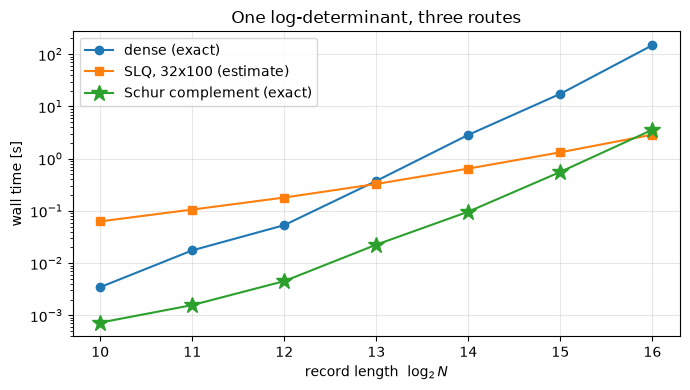

In [7]:
ks = [10, 11, 12, 13, 14, 15, 16]
K_DENSE_MAX = 16
rows = []
for k in ks:
    nn = 2 ** k
    oo = np.flatnonzero(np.asarray(gaps.periodic_mask(nn, N_GAP, PERIOD)) > 0)
    ee = gcg.circulant_eigenvalues([slq.ratio_spline(S_ref, knots, c_state)], nn, DT)
    row = {"k": k, "N": nn, "m": oo.size, "g": nn - oo.size}
    if k <= K_DENSE_MAX:
        t0 = time.perf_counter(); ld, _ = slq.logdet_dense(ee, oo)
        row["t_dense"], row["truth"] = time.perf_counter() - t0, ld
    t0 = time.perf_counter()
    r = slq.logdet_slq(ee, oo, 32, 100, np.random.default_rng(SEED))
    row["t_slq"], row["est_slq"] = time.perf_counter() - t0, r["est"]
    t0 = time.perf_counter()
    fc = slq.ComplementFactor(ee, oo)
    row["t_comp"], row["est_comp"] = time.perf_counter() - t0, fc.logdet
    rows.append(row)
    e_s = abs(row["est_slq"] - row.get("truth", row["est_comp"]))
    e_c = (abs(row["est_comp"] - row["truth"]) if "truth" in row else float("nan"))
    print(f"k={k:2d}  dense {row.get('t_dense', float('nan')):7.3f}s  "
          f"SLQ {row['t_slq']:6.3f}s (|err| {e_s:8.2f})  "
          f"complement {row['t_comp']:7.4f}s (|err| {e_c:.2e})")

fig, ax = plt.subplots(figsize=(7, 4))
kk = [r["k"] for r in rows]
ax.semilogy(kk, [r.get("t_dense", np.nan) for r in rows], "o-",  label="dense (exact)")
ax.semilogy(kk, [r["t_slq"]  for r in rows], "s-",  label="SLQ, 32x100 (estimate)")
ax.semilogy(kk, [r["t_comp"] for r in rows], "*-",  ms=12,
            label="Schur complement (exact)")
ax.set_xlabel(r"record length  $\log_2 N$"); ax.set_ylabel("wall time [s]")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("One log-determinant, three routes")
plt.tight_layout(); plt.show()

## Conclusions, caveats, and where each route wins

| route | nature | cost drivers | wins when |
|---|---|---|---|
| dense Cholesky | exact | $\mathcal O(m^3)$ flops, $\mathcal O(m^2)$ memory | small $m$; truth standard |
| SLQ, shared-probe differences | estimate ($\sim0.2$–$0.4$ LL at MCMC steps, 16 probes) | $2Mk$ FFT matvecs, batched | both $m$ *and* $g$ large |
| **Schur complement** | **exact** ($\sim10^{-9}$ LL) | one $g\times g$ Cholesky, reused for quadratic forms | $g \ll$ affordable-dense (to $N\!\sim\!2^{15}$–$2^{16}$ at 80% duty) |

**Caveats an expert should check:** (i) all of this lives in the *circulant* stationary model — the model the `gaplike` exact likelihood is defined on; strict-Toeplitz stationarity would need Szegő/Levinson support for $\log|\Sigma|$. (ii) The DC downdate is exact but its conditioning window matters (sweep above). (iii) No-reorth SLQ is validated empirically on these operators, not proven generally. (iv) Timings are multithreaded single-shot; the paper scripts report minima over repeats; single-threaded numbers (as in the companion paper) differ by the core count. (v) The leading-edge-truncation (premerger) configuration is structurally Toeplitz and admits further exact routes (Levinson streaming, Szegő asymptotics) — deliberately left as the next study.

**Reproducibility:** `pytest tests/test_slq.py` pins every claim used here; `paper/fig_det_scaling.py`, `paper/fig_det_flexible.py`, `paper/mkfig_det.py` regenerate the study figures; `SUMMARY.md` records the full findings with provenance.